In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
def getStoi(ch:str):
    if ch == '.':
        return 0
    else:
        return ord(ch) - ord('a') + 1

def getItos(n:int):
    if n == 0:
        return '.'
    else :
        return chr(n + ord('a')-1)

In [4]:
# build the dataset
def build_dataset(words):
    # Create the training set of bigrams
    block_size = 3 #context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
        #print(w)
        context = [0] * block_size 
        for ch in w + '.':
            ix = getStoi(ch)
            X.append(context)
            Y.append(ix)
            #print(''.join(getItos(i) for i in context), '--->', getItos(ix))
            context = context[1:] + [ix] #crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [5]:
Xtr.shape, Xtr.dtype, Ytr.shape, Ytr.dtype

(torch.Size([182625, 3]), torch.int64, torch.Size([182625]), torch.int64)

In [46]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn([200, 27], generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [47]:
sum(p.nelement() for p in parameters)

11897

In [48]:
for p in parameters:
    p.requires_grad = True

In [24]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [56]:
lri = []
lossi = []
for i in range(50000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (64,))
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
          
    # backward pass
    for p in parameters:
        p.grad = None
        
    loss.backward()
    
    # update
    #lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += (-lr * p.grad)

    # # track stats
    # lri.append(lre)
    # lossi.append(loss.item())

print(loss.item())

2.2187297344207764


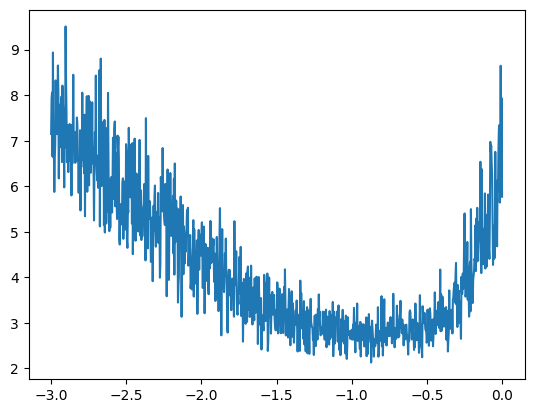

In [121]:
plt.plot(lre, lossi)

In [58]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1922, grad_fn=<NllLossBackward0>)

In [57]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1653, grad_fn=<NllLossBackward0>)

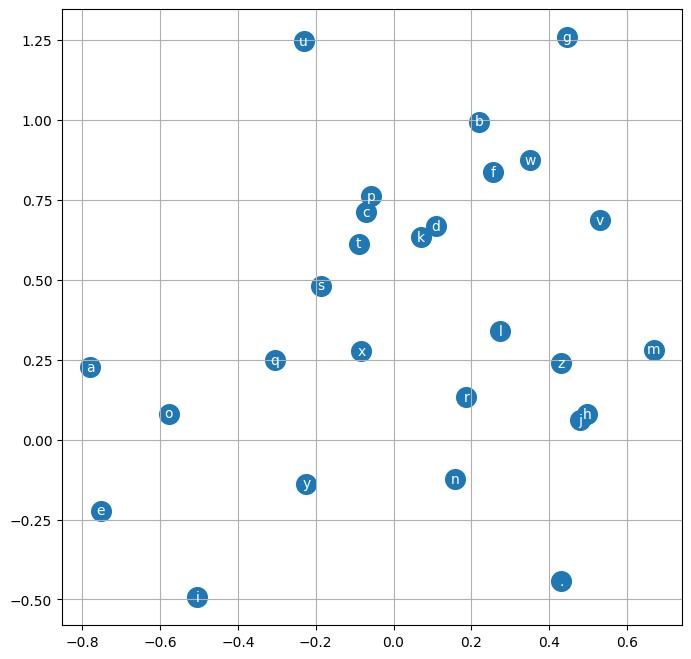

In [45]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s= 200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), getItos(i), ha="center", va="center", color="white")
plt.grid('minor')

In [60]:
g = torch.Generator().manual_seed(2147483647)

block_size =3

for _  in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break
    print(''.join(getItos(i) for i in out))

dex.
maleah.
makilah.
tyhammilima.
tainella.
kaman.
arreeryne.
javer.
gotti.
molise.
kau.
keitedo.
kaley.
maside.
enkamirry.
fobs.
milline.
vorleysh.
dedri.
anell.
